# Logistic Regression for Binary Classification

This notebook applies Logistic Regression to a binary classification problem. It covers data inspection, train-test splitting, a simple baseline, model training, evaluation, error analysis, and coefficient interpretation.

The dataset used in this version is included with Scikit-learn, so the notebook can run without an external file.

## 1. How Logistic Regression Produces a Probability

Logistic regression begins by calculating a linear score:

$$
z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

Because this score can be any real number, it is passed through the sigmoid function:

$$
P(y = 1 \mid \mathbf{x}) = \frac{1}{1 + e^{-z}}
$$

The sigmoid function converts the linear score into a probability between (0) and (1).

Using the default classification threshold:

$$
\hat{y} =
\begin{cases}
1, & \text{if } P(y = 1 \mid \mathbf{x}) \geq 0.5, \
0, & \text{if } P(y = 1 \mid \mathbf{x}) < 0.5.
\end{cases}
$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option('display.max_columns', 50)

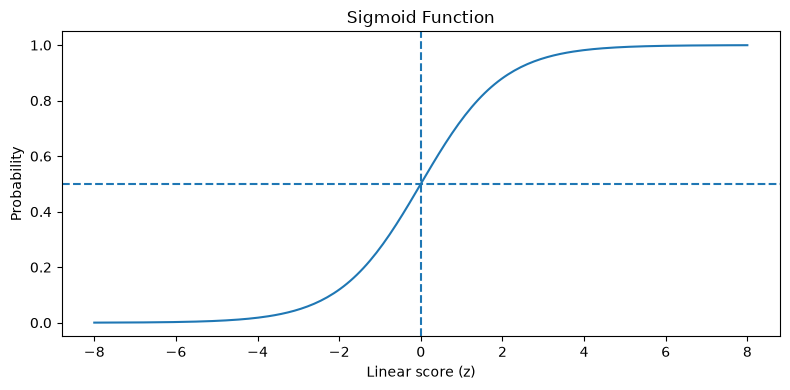

,linear_score_z,probability
0,-5,0.0067
1,-2,0.1192
2,0,0.5000
3,2,0.8808
4,5,0.9933


In [2]:
def sigmoid(z):
    # Convert a linear score into a probability between 0 and 1.
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-8, 8, 200)
probabilities = sigmoid(z_values)

plt.figure(figsize=(8, 4))
plt.plot(z_values, probabilities)
plt.axhline(0.5, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title('Sigmoid Function')
plt.xlabel('Linear score (z)')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

pd.DataFrame({
    'linear_score_z': [-5, -2, 0, 2, 5],
    'probability': sigmoid(np.array([-5, -2, 0, 2, 5]))
}).round(4)

## 2. Loading the Dataset

Each row represents one medical examination. The input columns contain measurements calculated from a digitized image of a breast mass.

The original dataset labels are:

- `0`: malignant
- `1`: benign

For this notebook, the target is reversed so that:

- `0`: benign
- `1`: malignant

This makes the medically important class the positive class, which keeps precision and recall easier to interpret.

In [3]:
dataset = load_breast_cancer(as_frame=True)

X = dataset.data.copy()
y = (dataset.target == 0).astype(int)
y.name = 'malignant'

df = X.copy()
df['malignant'] = y

print('Dataset shape:', df.shape)
print('Number of features:', X.shape[1])
df.head()

Dataset shape: (569, 31)
Number of features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Initial Checks

Before training, the dataset is checked for missing values, duplicate rows, data types, and class distribution. These checks confirm that the data is ready for modeling.

In [4]:
inspection = pd.DataFrame({
    'dtype': X.dtypes.astype(str),
    'missing_values': X.isna().sum(),
    'unique_values': X.nunique(),
})

print('Missing values in features:', int(X.isna().sum().sum()))
print('Missing values in target:', int(y.isna().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

inspection.head(10)

Missing values in features: 0
Missing values in target: 0
Duplicate rows: 0


,dtype,missing_values,unique_values
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


In [5]:
target_distribution = pd.DataFrame({
    'count': y.value_counts().sort_index(),
    'proportion': y.value_counts(normalize=True).sort_index(),
})

target_distribution.index = ['Benign (0)', 'Malignant (1)']
target_distribution

,count,proportion
Benign (0),357,0.627417
Malignant (1),212,0.372583


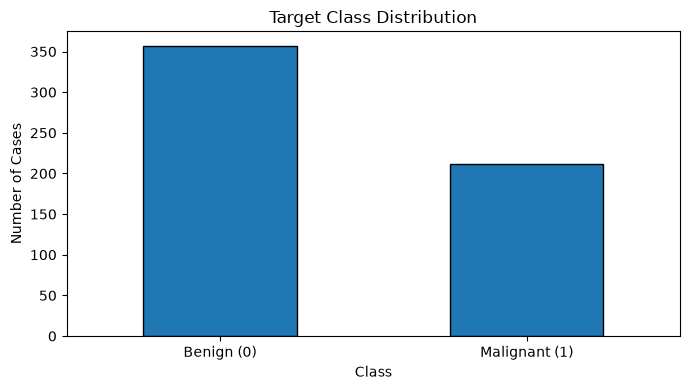

In [6]:
target_distribution['count'].plot(
    kind='bar',
    figsize=(7, 4),
    edgecolor='black'
)

plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The two classes are not perfectly balanced, but both have enough observations for training and evaluation. Because the positive class is less frequent, accuracy alone will not be enough to judge the model.

## 4. Stratified Train-Test Split

The model must be evaluated on observations it did not see during training.

`stratify=y` keeps approximately the same class proportions in the training and testing sets. The random state fixes the split so that the notebook produces the same result when it is run again.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    'subset': ['Training', 'Testing'],
    'rows': [len(X_train), len(X_test)],
    'malignant_proportion': [y_train.mean(), y_test.mean()],
})

split_summary

,subset,rows,malignant_proportion
0,Training,455,0.373626
1,Testing,114,0.368421


## 5. Baseline Model

A baseline gives a simple reference for comparison. The model below ignores the features and always predicts the most frequent class in the training set.

In [8]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

print(
    'Baseline accuracy:',
    round(accuracy_score(y_test, baseline_predictions), 4)
)

Baseline accuracy: 0.6316


## 6. Logistic Regression Pipeline

The pipeline first standardizes the numeric features, then trains Logistic Regression. Keeping both steps in one pipeline ensures that scaling is learned from the training data only.

In [9]:
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

logistic_model.fit(X_train, y_train)

print('Training completed.')

Training completed.


## 7. Predictions and Probabilities

`predict()` returns the final class after applying the decision threshold.

`predict_proba()` returns the probability assigned to each class. In binary classification, the second column is the estimated probability of the positive class.

In [10]:
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

prediction_preview = pd.DataFrame({
    'actual_class': y_test,
    'malignant_probability': logistic_probabilities,
    'predicted_class': logistic_predictions,
})

prediction_preview.head(12).round(4)

,actual_class,malignant_probability,predicted_class
120,0,0.0004,0
250,1,1.0000,1
375,0,0.0426,0
99,1,0.5762,1
455,0,0.5092,1
318,0,0.0006,0
39,1,0.7615,1
371,0,0.0010,0
98,0,0.0006,0
502,0,0.0108,0


## 8. Model Evaluation

The model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Recall is especially important here because a false negative means that a malignant case was predicted as benign.

In [11]:
def calculate_metrics(y_true, predictions, probabilities):
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1_score': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probabilities),
    }

results = pd.DataFrame([
    {
        'model': 'Most-Frequent Baseline',
        **calculate_metrics(
            y_test,
            baseline_predictions,
            baseline_probabilities,
        ),
    },
    {
        'model': 'Logistic Regression',
        **calculate_metrics(
            y_test,
            logistic_predictions,
            logistic_probabilities,
        ),
    },
])

results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Most-Frequent Baseline,0.6316,0.000,0.0000,0.0000,0.500
1,Logistic Regression,0.9649,0.975,0.9286,0.9512,0.996


The baseline may obtain a reasonable-looking accuracy because it repeatedly predicts the majority class. Its recall and F1-score for malignant cases reveal that it is not useful.

Logistic Regression should be judged by whether it improves the full group of metrics, not by accuracy alone.

## 9. Classification Report

The classification report presents precision, recall, and F1-score separately for both classes. This helps reveal whether the model performs well for one class but poorly for the other.

In [12]:
report = classification_report(
    y_test,
    logistic_predictions,
    target_names=['Benign', 'Malignant'],
    output_dict=True,
    zero_division=0,
)

report_table = pd.DataFrame(report).T
report_table.round(4)

,precision,recall,f1-score,support
Benign,0.9595,0.9861,0.9726,72.0000
Malignant,0.9750,0.9286,0.9512,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9672,0.9573,0.9619,114.0000
weighted avg,0.9652,0.9649,0.9647,114.0000


## 10. Confusion Matrix

The confusion matrix separates the predictions into four groups:

- **True Negative:** benign case predicted as benign
- **False Positive:** benign case predicted as malignant
- **False Negative:** malignant case predicted as benign
- **True Positive:** malignant case predicted as malignant

This view makes the model's errors easier to understand than a single score.

In [13]:
cm = confusion_matrix(y_test, logistic_predictions)
tn, fp, fn, tp = cm.ravel()

error_summary = pd.DataFrame({
    'outcome': [
        'True Negative',
        'False Positive',
        'False Negative',
        'True Positive',
    ],
    'count': [tn, fp, fn, tp],
})

error_summary

,outcome,count
0,True Negative,71
1,False Positive,1
2,False Negative,3
3,True Positive,39


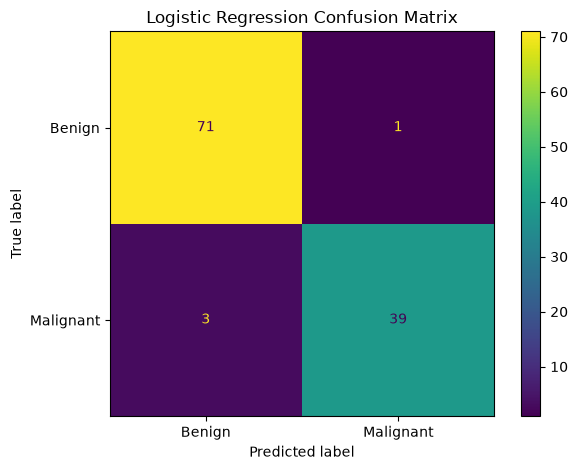

In [14]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benign', 'Malignant'],
).plot(values_format='d')

plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

## 11. ROC Curve

The ROC curve evaluates the model across many possible thresholds instead of using only 0.5.

A curve closer to the upper-left corner indicates better separation between the two classes. The diagonal line represents random ranking.

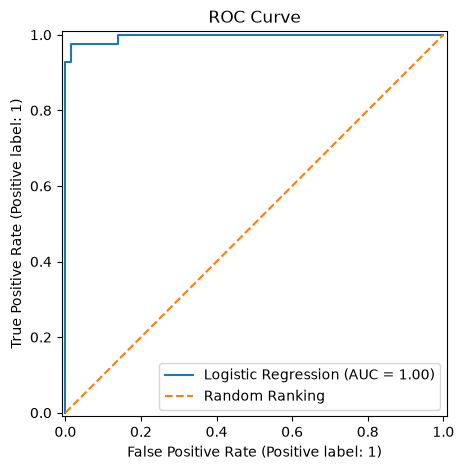

In [15]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name='Logistic Regression',
)

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Ranking')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Coefficient Interpretation

Logistic Regression learns one coefficient for each feature.

- Positive coefficients push the prediction toward the positive class.
- Negative coefficients push the prediction toward the negative class.
- Larger absolute values indicate a stronger effect on the model score.

These coefficients describe associations in the data, not causal relationships.

In [16]:
trained_logistic_regression = (
    logistic_model.named_steps['logisticregression']
)

coefficient_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': trained_logistic_regression.coef_[0],
})

coefficient_table['absolute_coefficient'] = (
    coefficient_table['coefficient'].abs()
)

coefficient_table = coefficient_table.sort_values(
    'absolute_coefficient',
    ascending=False,
)

coefficient_table.head(12).round(4)

,feature,coefficient,absolute_coefficient
21,worst texture,1.4341,1.4341
10,radius error,1.2333,1.2333
28,worst symmetry,1.0613,1.0613
7,mean concave points,0.9528,0.9528
26,worst concavity,0.9114,0.9114
13,area error,0.9090,0.9090
15,compactness error,-0.9069,0.9069
23,worst area,0.9005,0.9005
20,worst radius,0.8970,0.8970
6,mean concavity,0.7823,0.7823


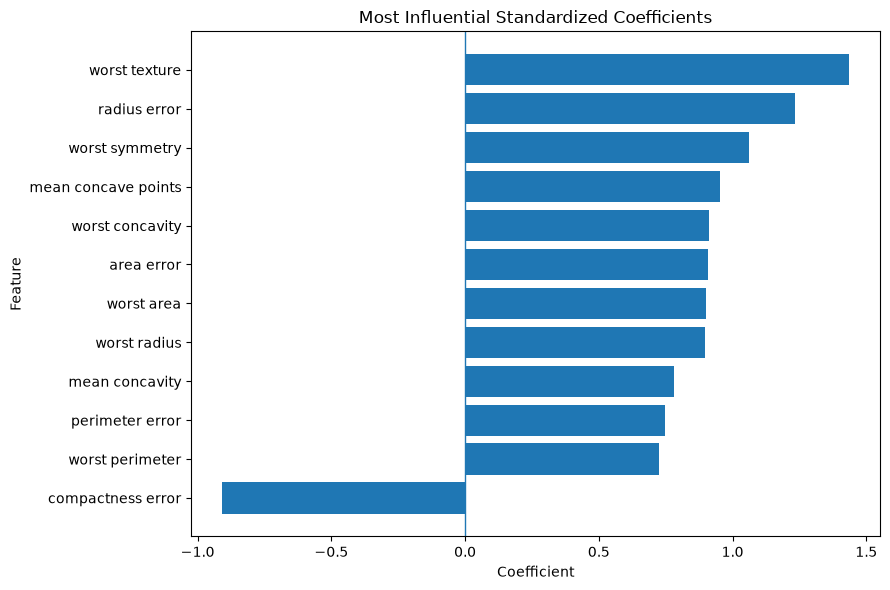

In [17]:
top_coefficients = (
    coefficient_table
    .head(12)
    .sort_values('coefficient')
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_coefficients['feature'],
    top_coefficients['coefficient'],
)
plt.axvline(0, linewidth=1)
plt.title('Most Influential Standardized Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 13. Conclusion

The Logistic Regression model was compared with a most-frequent baseline and evaluated on a separate test set.

The notebook used a reproducible train-test split, feature scaling inside a pipeline, several classification metrics, a confusion matrix, an ROC curve, and coefficient inspection.

The next step is to apply the same workflow to the project dataset and compare Logistic Regression with other classifiers.